In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("Global_Mental_Health_Dataset_2025.csv")
print(df.head())

  Patient_ID  Age  Gender        Country  Depression_Score  Anxiety_Score  \
0     MH0001   56    Male        Germany                 4             10   
1     MH0002   69    Male   South Africa                22              4   
2     MH0003   46    Male   South Africa                 4              2   
3     MH0004   32  Female      Australia                19             16   
4     MH0005   60  Female  United States                14              1   

  Stress_Level  Sleep_Hours Physical_Activity Chronic_Illness  \
0         High          8.2          Moderate              No   
1       Severe          6.2               Low              No   
2          Low         10.4               NaN             Yes   
3          Low         10.0          Moderate              No   
4       Severe          7.9               Low             Yes   

  Mental_Health_History   Treatment  Days_of_Treatment    Outcome Work_Status  
0                    No     Therapy                171  Excellent 

In [9]:
#Checking Data Info
print("\nDataset Info:\n")
print(df.info())

print("\nColumn Names:\n")
print(df.columns)

#Checking missing values
print(df.isna().sum())


Dataset Info:

<class 'pandas.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Gender            2500 non-null   str  
 1   Age               2500 non-null   int64
 2   Depression_Score  2500 non-null   int64
 3   Anxiety_Score     2500 non-null   int64
dtypes: int64(3), str(1)
memory usage: 78.3 KB
None

Column Names:

Index(['Gender', 'Age', 'Depression_Score', 'Anxiety_Score'], dtype='str')
Gender              0
Age                 0
Depression_Score    0
Anxiety_Score       0
dtype: int64


In [6]:
print(df.columns.tolist())

['Patient_ID', 'Age', 'Gender', 'Country', 'Depression_Score', 'Anxiety_Score', 'Stress_Level', 'Sleep_Hours', 'Physical_Activity', 'Chronic_Illness', 'Mental_Health_History', 'Treatment', 'Days_of_Treatment', 'Outcome', 'Work_Status']


In [7]:
#Selecting Required Columns
#Depression_Score = PHQ-9 Equivalent
#Anxiety_Score = GAD-7 Equivalent
df = df[[
    "Gender",
    "Age",
    "Depression_Score",
    "Anxiety_Score"
]]

print(df.head())


   Gender  Age  Depression_Score  Anxiety_Score
0    Male   56                 4             10
1    Male   69                22              4
2    Male   46                 4              2
3  Female   32                19             16
4  Female   60                14              1


In [10]:
#Creating Age groups
bins = [0, 18, 30, 45, 60, 100]

labels = [
    "0-18",
    "19-30",
    "31-45",
    "46-60",
    "60+"
]

df["Age_Group"] = pd.cut(
    df["Age"],
    bins=bins,
    labels=labels
)

In [11]:
#Saving cleaned dataset
df.to_csv(
    "cleaned_phq_gad_dataset.csv",
    index=False
)

print("\nCleaned dataset saved successfully.")



Cleaned dataset saved successfully.


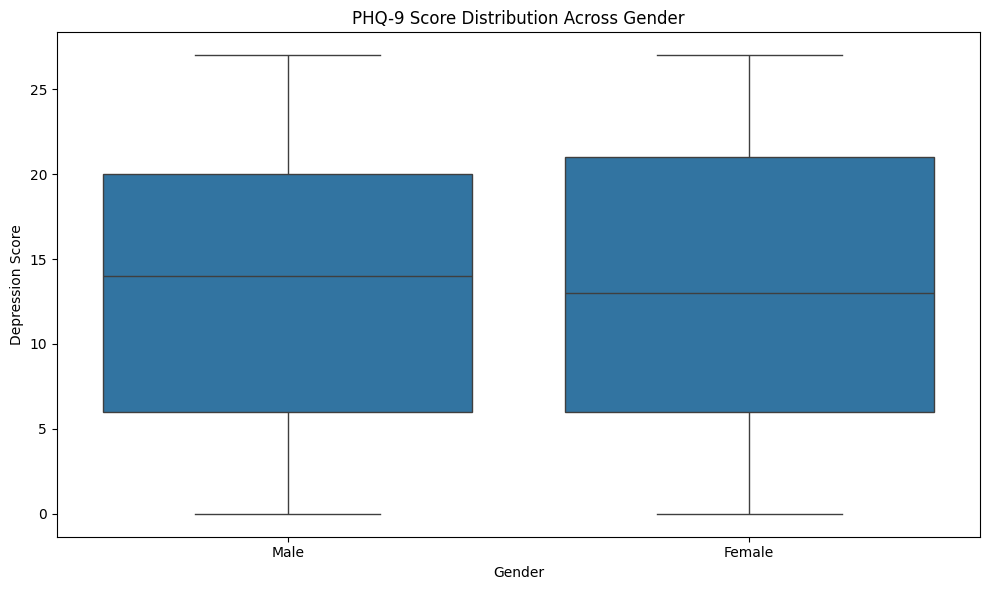

In [13]:
#PHQ-9 Gender Distribution Boxplot
plt.figure(figsize=(10,6))

sns.boxplot(
    x="Gender",
    y="Depression_Score",
    data=df
)

plt.title(
    "PHQ-9 Score Distribution Across Gender"
)

plt.xlabel("Gender")

plt.ylabel("Depression Score")

plt.tight_layout()

plt.savefig(
    "PHQ_Gender_Boxplot.png"
)

plt.show()

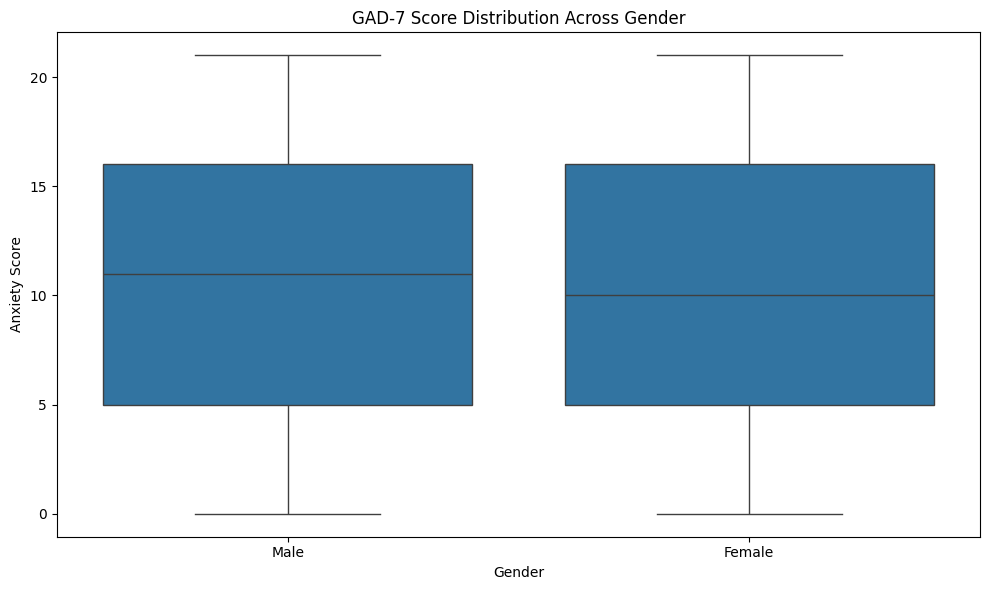

In [14]:
#GAD Gender Box Plot
plt.figure(figsize=(10,6))

sns.boxplot(
    x="Gender",
    y="Anxiety_Score",
    data=df
)

plt.title(
    "GAD-7 Score Distribution Across Gender"
)

plt.xlabel("Gender")

plt.ylabel("Anxiety Score")

plt.tight_layout()

plt.savefig(
    "GAD_Gender_Boxplot.png"
)

plt.show()

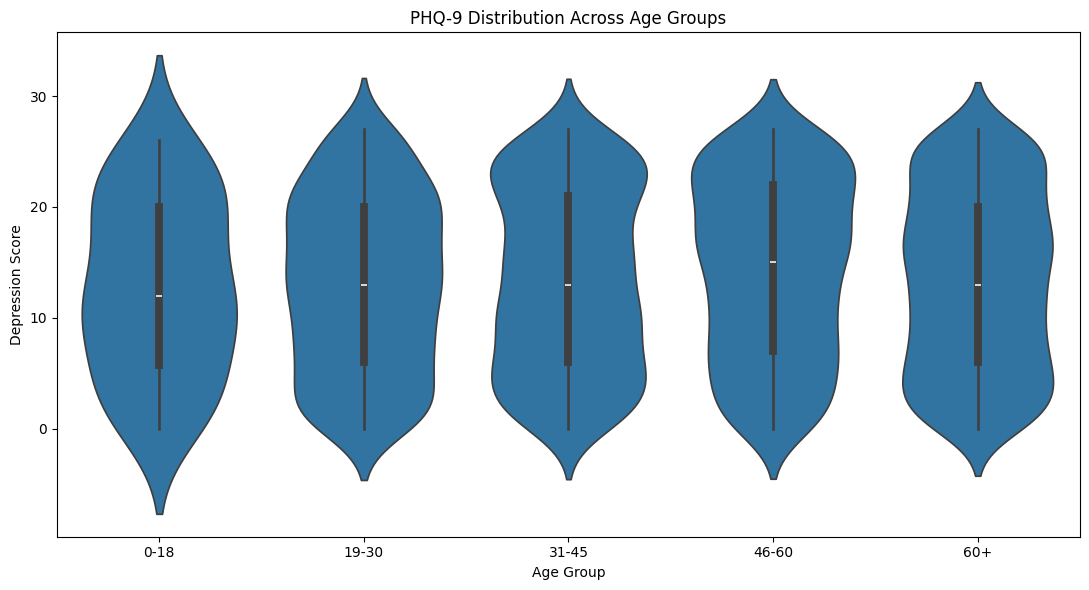

In [15]:
#PHQ Age Violin Plot
plt.figure(figsize=(11,6))

sns.violinplot(
    x="Age_Group",
    y="Depression_Score",
    data=df
)

plt.title(
    "PHQ-9 Distribution Across Age Groups"
)

plt.xlabel("Age Group")

plt.ylabel("Depression Score")

plt.tight_layout()

plt.savefig(
    "PHQ_Age_Violinplot.png"
)

plt.show()

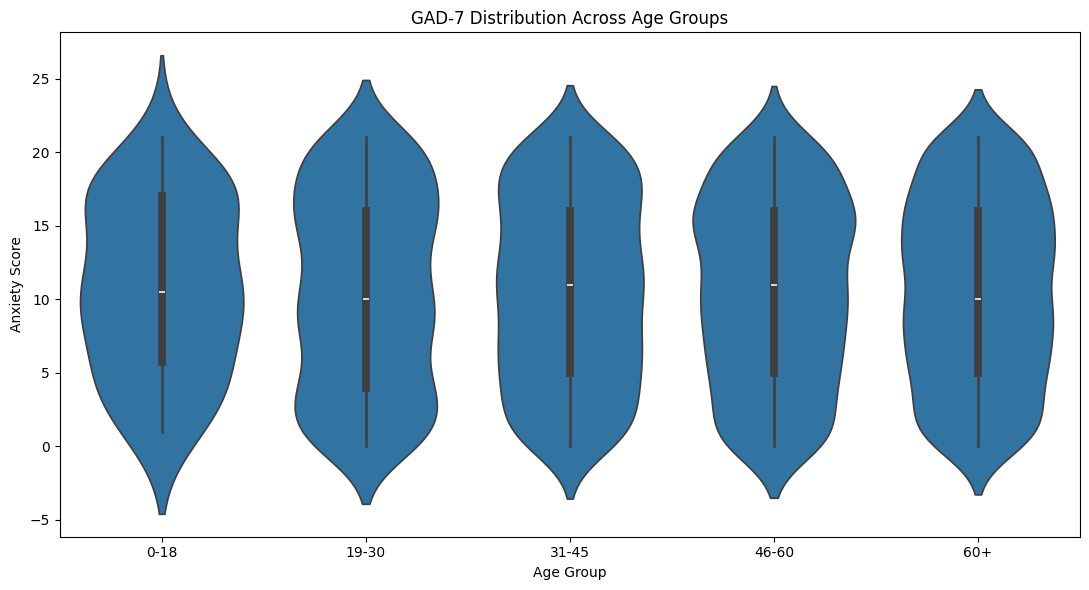

In [16]:
#GAD Age Violin Plot
plt.figure(figsize=(11,6))

sns.violinplot(
    x="Age_Group",
    y="Anxiety_Score",
    data=df
)

plt.title(
    "GAD-7 Distribution Across Age Groups"
)

plt.xlabel("Age Group")

plt.ylabel("Anxiety Score")

plt.tight_layout()

plt.savefig(
    "GAD_Age_Violinplot.png"
)

plt.show()

In [17]:
summary_stats = df[[
    "Depression_Score",
    "Anxiety_Score"
]].describe()

print(summary_stats)

       Depression_Score  Anxiety_Score
count       2500.000000    2500.000000
mean          13.518400      10.502800
std            8.082561       6.329267
min            0.000000       0.000000
25%            6.000000       5.000000
50%           14.000000      11.000000
75%           21.000000      16.000000
max           27.000000      21.000000
